In [23]:
# Data preprocessing and loading 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader 
# Network initalization 
import torch 
import torch.nn as nn 
import torch.nn.functional as F

In [15]:
train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [16]:
train = datasets.ImageFolder(root=r"D:\Model Knowledge Base\CNN\Seha CNN project\images\train", transform=train_transforms)

In [17]:
train_loader = DataLoader(train, batch_size=32,shuffle=True,num_workers=4)

In [18]:
images, labels = next(iter(train_loader))

In [19]:
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [ ]:
# Initlizaing the Network 

class CustomCNN(nn.Module):
    def __init__(self, num_classes = 3):
        super(CustomCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        
        self.pool  = nn.MaxPool2d(2,2)
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        self.fc1  = nn.Linear(32*16*16 , 128)
        self.fc2  = nn.Linear(128, num_classes)
        
    def forward (self, x):
        
        x = self.pool(F.relu(self.conv1(x)))
        
        x = self.pool(F.relu(self.conv2(x)))
        
        x = x.view(x.size(0),-1)
        
        x = F.relu(self.fc1(x))
        
        x = self.fc2(x)
        
        return x 

Epoch [1/20] Loss: 17.4856 Accuracy: 32.92%
Epoch [2/20] Loss: 12.2961 Accuracy: 60.42%
Epoch [3/20] Loss: 8.7279 Accuracy: 67.29%
Epoch [4/20] Loss: 7.9000 Accuracy: 69.79%
Epoch [5/20] Loss: 8.4570 Accuracy: 70.00%
Epoch [6/20] Loss: 7.2369 Accuracy: 75.62%
Epoch [7/20] Loss: 6.5212 Accuracy: 78.33%
Epoch [8/20] Loss: 5.2220 Accuracy: 82.50%
Epoch [9/20] Loss: 4.4094 Accuracy: 87.08%
Epoch [10/20] Loss: 3.7956 Accuracy: 88.75%
Epoch [11/20] Loss: 3.3289 Accuracy: 91.67%
Epoch [12/20] Loss: 3.0975 Accuracy: 92.08%
Epoch [13/20] Loss: 2.6863 Accuracy: 91.88%
Epoch [14/20] Loss: 2.2799 Accuracy: 95.00%
Epoch [15/20] Loss: 1.4368 Accuracy: 96.46%
Epoch [16/20] Loss: 1.7746 Accuracy: 95.21%
Epoch [17/20] Loss: 1.2391 Accuracy: 97.71%
Epoch [18/20] Loss: 1.2696 Accuracy: 97.08%
Epoch [19/20] Loss: 1.2064 Accuracy: 96.46%
Epoch [20/20] Loss: 0.9056 Accuracy: 97.92%

Test Accuracy: 95.83%


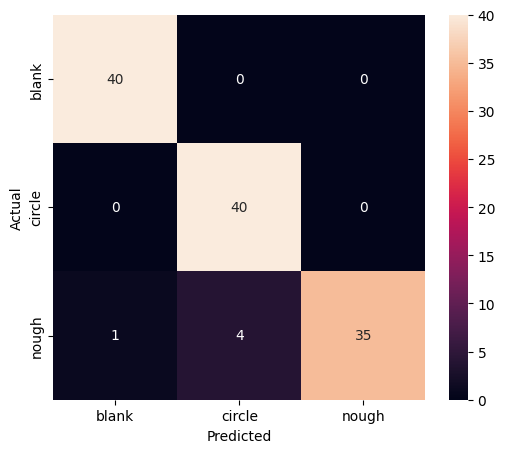

              precision    recall  f1-score   support

       blank       0.98      1.00      0.99        40
      circle       0.91      1.00      0.95        40
       nough       1.00      0.88      0.93        40

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------
# 1️⃣ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------
# 2️⃣ Transforms
train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.1,0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# --------------------------
# 3️⃣ Datasets & Loaders
train_dataset = datasets.ImageFolder(root= r"D:\Model Knowledge Base\CNN\Seha CNN project\images\train", transform=train_transforms)
test_dataset  = datasets.ImageFolder(root= r"D:\Model Knowledge Base\CNN\Seha CNN project\images\test",  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --------------------------
# 4️⃣ Custom CNN
class CustomCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc1 = nn.Linear(32*16*16, 128)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CustomCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()  # simple, no weighted loss

# --------------------------
# 5️⃣ Training Loop
num_epochs = 20  # ممكن تزود لو dataset صغير
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss:.4f} Accuracy: {acc:.2f}%")

# --------------------------
# 6️⃣ Testing Loop + Confusion Matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
test_acc = 100 * sum(np.array(all_preds)==np.array(all_labels)) / len(all_labels)
print(f"\nTest Accuracy: {test_acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))
